Import libralies

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix




In [4]:
# Load the dataset
df= pd.read_csv('D:\\Movies_Reviews_modified_version1.csv\\Movies_Reviews_modified_version1.csv')

In [5]:
df.head()

,Unnamed: 0,Ratings,Reviews,movie_name,Resenhas,genres,Description,emotion
0,0,3.0,"It had some laughs, but overall the motivation...",Waiting to Exhale,"Riu algumas risadas, mas no geral a motivação ...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation
1,1,4.0,"WAITING TO EXHALE Waiting, and waiting, and wa...",Waiting to Exhale,"ESPERANDO PARA EXALAR Esperando, e esperando, ...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation
2,2,4.0,"Angela Basset was good as expected, but Whitne...",Waiting to Exhale,"Angela Basset foi boa como o esperado, mas Whi...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation
3,3,5.0,"The movie is okay, mediocre might even be the ...",Waiting to Exhale,"O filme é bom, medíocre pode até ser a palavra...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation
4,4,5.0,I got an opportunity to see Waiting To Exhale ...,Waiting to Exhale,Tive a oportunidade de ver Waiting To Exhale p...,"['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation


In [6]:
# Keep required columns
df = df[['Reviews', 'Ratings']]



In [7]:
# Remove missing values
df.dropna(inplace=True)

In [8]:
df.head()

,Reviews,Ratings
0,"It had some laughs, but overall the motivation...",3.0
1,"WAITING TO EXHALE Waiting, and waiting, and wa...",4.0
2,"Angela Basset was good as expected, but Whitne...",4.0
3,"The movie is okay, mediocre might even be the ...",5.0
4,I got an opportunity to see Waiting To Exhale ...,5.0


In [9]:
# Create Sentiment Labels from Ratings

def get_sentiment(rating):
    if rating >= 4:
        return "positive"
    elif rating == 3:
        return "neutral"
    else:
        return "negative"

df["Sentiment"] = df["Ratings"].apply(get_sentiment)

In [10]:
# Text Preprocessing

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)
    
    # Remove numbers
    text = re.sub(r"\d+", "", text)
    
    # Remove punctuation
    text = re.sub(r"[^\w\s]", "", text)
    
    # Tokenization
    words = text.split()
    
    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]
    
    return " ".join(words)

df["Clean_Review"] = df["Reviews"].apply(preprocess_text)



In [44]:
# Feature Extraction using TF-IDF

tfidf = TfidfVectorizer(
    max_features=500,
    ngram_range=(1,2)
)

X = tfidf.fit_transform(df["Clean_Review"])
y = df["Sentiment"]


In [45]:
df.head()

,Reviews,Ratings,Sentiment,Clean_Review
0,"It had some laughs, but overall the motivation...",3.0,neutral,laugh overall motivation character incomprehen...
1,"WAITING TO EXHALE Waiting, and waiting, and wa...",4.0,positive,waiting exhale waiting waiting waiting waiting...
2,"Angela Basset was good as expected, but Whitne...",4.0,positive,angela basset good expected whitney range actr...
3,"The movie is okay, mediocre might even be the ...",5.0,positive,movie okay mediocre might even word describe s...
4,I got an opportunity to see Waiting To Exhale ...,5.0,positive,got opportunity see waiting exhale second time...


In [46]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



In [47]:
# Train Logistic Regression Model

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [48]:
# Prediction

y_pred = model.predict(X_test)

In [49]:
# Evaluation

print("Accuracy :", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))



Accuracy : 0.8422306442880346

Classification Report:

              precision    recall  f1-score   support

    negative       0.72      0.61      0.66      1456
     neutral       0.67      0.28      0.39       867
    positive       0.87      0.96      0.91      6912

    accuracy                           0.84      9235
   macro avg       0.75      0.62      0.66      9235
weighted avg       0.83      0.84      0.82      9235


Confusion Matrix:

[[ 883   67  506]
 [ 135  243  489]
 [ 205   55 6652]]


In [50]:
# Test Custom Review

sample_review = """
The movie was fantastic. Acting and storyline were excellent.
"""

sample_review = preprocess_text(sample_review)

sample_vector = tfidf.transform([sample_review])

prediction = model.predict(sample_vector)

print("\nPredicted Sentiment:", prediction[0])


Predicted Sentiment: positive


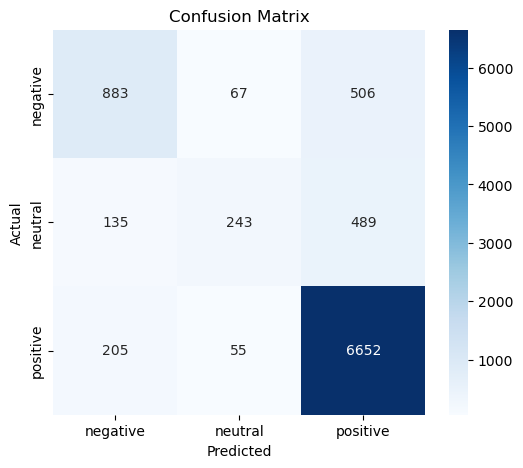

In [51]:
# confusion matrix 
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()